In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [39]:
p = Path('data/ibutton/2023_Season/Dan_C9+Heather')
paths = list(p.glob('*.csv'))
paths

[PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_RR.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_L.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_II.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_FF.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/C9_FF.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_H.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_JJ.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_Q.csv'),
 PosixPath('data/ibutton/2023_Season/Dan_C9+Heather/Heather_QQ.csv')]

In [60]:
p = Path('data/ibutton/2023_Season/Dan_C9+Heather')
paths = list(p.glob('*.csv'))
files = []
for path in paths:
    transect, sensor_id = path.stem.split('_')
    d = pd.read_csv(path, skiprows=15)
    d.columns = ['datetime', 'unit', 'T']
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['sensor_id'] = sensor_id
    d['transect'] = transect
    d['year'] = 2023
    d = d.drop(columns=['unit'])
    files.append(d)
df = pd.concat(files, ignore_index=True)
df

,datetime,T,sensor_id,transect,year
0,2023-07-17 00:10:00,11.5,RR,Heather,2023
1,2023-07-17 00:20:00,11.5,RR,Heather,2023
2,2023-07-17 00:30:00,11.5,RR,Heather,2023
3,2023-07-17 00:40:00,11.0,RR,Heather,2023
4,2023-07-17 00:50:00,11.0,RR,Heather,2023
...,...,...,...,...,...
7242,2023-07-16 23:12:00,11.5,QQ,C9,2023
7243,2023-07-16 23:22:00,11.5,QQ,C9,2023
7244,2023-07-16 23:32:00,11.5,QQ,C9,2023
7245,2023-07-16 23:42:00,11.5,QQ,C9,2023


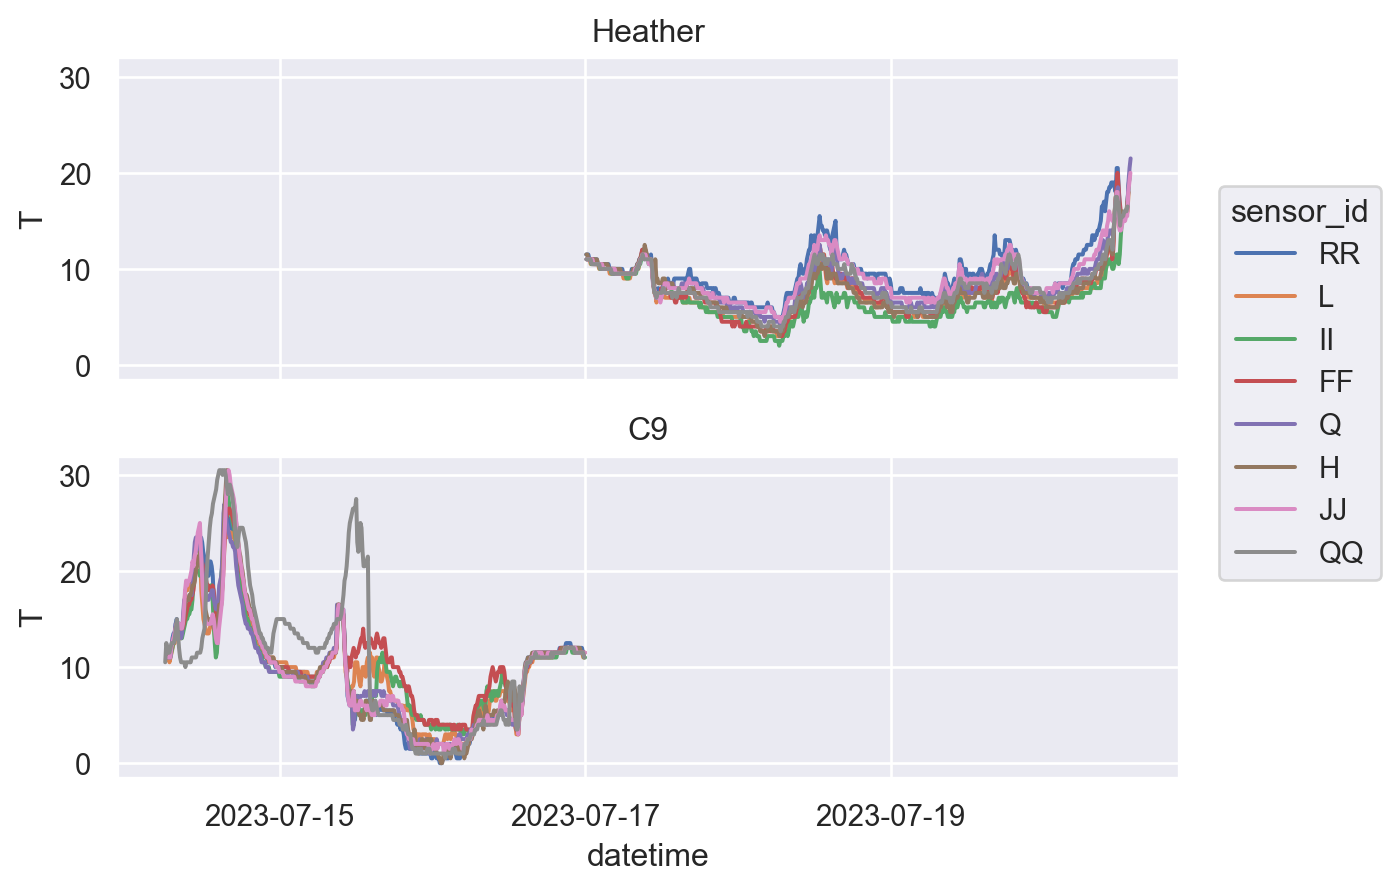

In [62]:
(
so.Plot(df, x='datetime', y='T', color='sensor_id')
    .facet(row='transect')
    .add(so.Line())
)